In [11]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [12]:
def calculate_press_plsr(X, sup_Y, Y, plsnum):
    """
    Calculate PRESS statistics and optionally VIP and VAR using PLS-R.

    Parameters:
        X (numpy.ndarray): Predictor data (n_samples x n_features).
        sup_Y (list of numpy.ndarray): List of supervision labels (per sample).
        Y (numpy.ndarray): Dependent variable (n_samples x n_outputs).
        plsnum (int): Number of PLS components.

    Returns:
        press (float): Predicted residual error sum of squares.
        VIP (numpy.ndarray): Variable importance in projection (optional).
        VAR (numpy.ndarray): Explained variance by components (optional).
    """
    n_samples = X.shape[0]
    pre = np.zeros(n_samples)
    VIP = np.full((n_samples, X.shape[1]), np.nan)
    VAR = np.full((n_samples, plsnum), np.nan)

    loo = LeaveOneOut()

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        sup_Y_train = [sup_Y[i] for i in train_idx]
        sup_Y_test = sup_Y[test_idx[0]]

        # Train PLS-R model
        pls = PLSRegression(n_components=plsnum)
        pls.fit(X_train, sup_Y_train)

        # Predict on test data
        sup_estY = pls.predict(X_test)
        T = np.linalg.pinv(sup_Y_test) @ Y_train
        estY = sup_estY @ T

        # Calculate prediction residual
        pre[test_idx[0]] = np.sum((Y_test - estY) ** 2)

        # Optional: Calculate VIP and VAR
        if plsnum > 0:
            VIP[test_idx[0], :] = calculate_vip(X_train, Y_train, pls)
            VAR[test_idx[0], :] = pls.explained_variance_ratio_

    press = np.sum(pre)
    return press, VIP, VAR

def calculate_vip(X, Y, pls):
    """
    Calculate Variable Importance in Projection (VIP) scores.
    
    Parameters:
        X (numpy.ndarray): Predictor data.
        Y (numpy.ndarray): Dependent variable.
        pls (PLSRegression): Trained PLS model.

    Returns:
        vip_scores (numpy.ndarray): VIP scores for features.
    """
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_

    s = np.diag(t.T @ t @ q.T @ q).reshape(-1, 1)
    total_s = np.sum(s)
    W = (w ** 2) * s / total_s
    vip_scores = np.sqrt(X.shape[1] * np.sum(W, axis=0))
    return vip_scores


In [13]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

def vip(X, Y, XS, XL, YL):
    """
    Compute Variable Importance in Projection (VIP) scores.
    """
    t = XS.shape[1]
    s = np.sum(YL ** 2, axis=0)
    w = (XL.T ** 2) * s
    total_s = np.sum(s)
    return np.sqrt(X.shape[1] * np.sum(w, axis=1) / total_s)

def press_plsr(X, sup_Y, Y, plsnum):
    """
    Calculate PRESS, VIP, and VAR using PLSR with LOOCV.
    
    Parameters:
        X: Predictor data (numpy array)
        sup_Y: List of supervised target data for LOOCV
        Y: Dependent data (numpy array)
        plsnum: Number of PLS components to use
        
    Returns:
        press: Predicted Residual Error Sum of Squares (float)
        VIP: Variable Importance in Projection scores (numpy array)
        VAR: Explained variance by each component (numpy array)
    """
    n = X.shape[0]
    pre = np.zeros(n)
    VIP = np.full((n, X.shape[1]), np.nan)
    VAR = np.full((n, plsnum), np.nan)

    for j in range(n):
        testdata = [j]
        supervisors = list(set(range(n)) - set(testdata))
        
        # Fit PLSR model
        pls = PLSRegression(n_components=plsnum)
        pls.fit(X[supervisors], sup_Y[j])
        
        # Estimate test data of Y from test data of X
        sup_estY = np.hstack([np.ones((1, 1)), X[testdata]]) @ np.vstack([pls.y_mean_, pls.x_weights_])
        
        # Change of basis
        T = np.linalg.pinv(sup_Y[j]) @ Y[supervisors]
        estY = sup_estY @ T
        
        # Calculate PRESS
        pre[j] = np.sum((estY - Y[testdata]) ** 2)
        
        # Calculate VIP scores
        VIP[j, :] = vip(X[supervisors], Y[supervisors], pls.x_scores_, pls.x_weights_, pls.y_loadings_)
        
        # Store explained variance
        VAR[j, :] = pls.explained_variance_ratio_

    # Sum of predicted residuals
    press = np.sum(pre)
    
    return press, VIP, VAR


In [14]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import LeaveOneOut, train_test_split
import anndata as ad

In [15]:
def pclda_with_validation(adata, group='cell_type', percent=98, test_size=0.2, random_state=42):
    """
    Perform PC-LDA on AnnData objects with validation.

    Parameters:
        adata (AnnData): Input AnnData with `.X` (data matrix) and `.obs[group]` (group labels).
        group (str): Column name in `adata.obs` representing group labels (default is 'group').
        percent (float): Variance explained threshold for PCA (default is 98%).
        test_size (float): Fraction of data used for testing (default is 0.2).
        random_state (int): Random seed for reproducibility.

    Returns:
        U_train (pd.DataFrame): Training data PC-LDA projections.
        U_test (pd.DataFrame): Testing data PC-LDA projections.
        accuracy (float): Classification accuracy on the test data.
        meanU (pd.DataFrame): Mean LDA projections for each group in training data.
    """
    # Extract data and labels
    X = adata.X
    group_labels = adata.obs[group].values

    # Split the data into training and testing sets
    X_train, X_test, group_train, group_test = train_test_split(
        X, group_labels, test_size=test_size, random_state=random_state, stratify=group_labels
    )

    # PCA on training data
    pca = PCA()
    X_train_pca = pca.fit_transform(X_train)

    # Calculate the number of PCs to retain based on the cumulative variance
    explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_) * 100
    nPCs = np.where(explained_variance_ratio > percent)[0][0] + 1

    # Transform training and testing data to PCA space
    X_train_pca = X_train_pca[:, :nPCs]
    X_test_pca = pca.transform(X_test)[:, :nPCs]

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_pca, group_train)
    X_train_lda = lda.transform(X_train_pca)
    X_test_lda = lda.transform(X_test_pca)

    # Classification and accuracy
    predictions = lda.predict(X_test_pca)
    accuracy = accuracy_score(group_test, predictions)

    # Calculate mean LDA projection (meanU) for each group in training data
    unique_groups = np.unique(group_train)
    meanU = pd.DataFrame(
        {group: X_train_lda[group_train == group].mean(axis=0) for group in unique_groups}
    ).T
    meanU.columns = [f"LDA_{i+1}" for i in range(X_train_lda.shape[1])]
    meanU.index.name = "group"

    # Format the projections into DataFrames
    U_train = pd.DataFrame(
        X_train_lda, columns=[f"LDA_{i+1}" for i in range(X_train_lda.shape[1])]
    )
    U_train['group'] = group_train

    U_test = pd.DataFrame(
        X_test_lda, columns=[f"LDA_{i+1}" for i in range(X_test_lda.shape[1])]
    )
    U_test['group'] = group_test

    return U_train, U_test, accuracy, meanU

def calculate_vip(X, Y, pls):
    """
    Calculate Variable Importance in Projection (VIP) scores.

    Parameters:
        X (np.ndarray): Input features.
        Y (np.ndarray): Target variables.
        pls (PLSRegression): Trained PLS model.

    Returns:
        vip_scores (np.ndarray): VIP scores for each feature.
    """
    t = pls.x_scores_  # Shape: (n_samples, n_components)
    w = pls.x_weights_  # Shape: (n_features, n_components)
    q = pls.y_loadings_  # Shape: (n_components, n_targets)

    # Compute s (explained variance contribution per component)
    s = np.diag(t.T @ t @ q.T @ q)  # Shape: (n_components,)
    s = s.reshape(1, -1)  # Reshape to (1, n_components) for broadcasting
    total_s = np.sum(s)  # Total explained variance

    # Compute weighted importance
    W = (w ** 2) * s / total_s  # Shape: (n_features, n_components)

    # Sum over components and take the square root
    vip_scores = np.sqrt(X.shape[1] * np.sum(W, axis=1))  # Shape: (n_features,)
    return vip_scores

def plot_pclda(U_train, U_test, dims=(1, 2), title="PC-LDA Visualization"):
    """
    Plot PC-LDA projections in 2D or 3D and save the plots as PDF files.

    Parameters:
        U_train (pd.DataFrame): Training data PC-LDA projections.
        U_test (pd.DataFrame): Testing data PC-LDA projections.
        dims (tuple): Dimensions to plot (default is (1, 2)).
        title (str): Plot title.
    """
    fig = plt.figure(figsize=(10, 8))

    # Define consistent colors for groups
    unique_groups = U_train['group'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
    group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

    if len(dims) == 2:
        ax = fig.add_subplot(111)
        for group in unique_groups:
            group_data_train = U_train[U_train['group'] == group]
            group_data_test = U_test[U_test['group'] == group]

            # Plot train data
            ax.scatter(
                group_data_train[f"LDA_{dims[0]}"],
                group_data_train[f"LDA_{dims[1]}"],
                label=f"Train: {group}",
                color=group_color_map[group],
                alpha=0.7
            )

            # Plot test data with edgecolor
            ax.scatter(
                group_data_test[f"LDA_{dims[0]}"],
                group_data_test[f"LDA_{dims[1]}"],
                label=f"Test: {group}",
                color=group_color_map[group],
                edgecolor="k",
                alpha=0.9,
                linewidth=1.5
            )
        ax.set_xlabel(f"LDA {dims[0]}")
        ax.set_ylabel(f"LDA {dims[1]}")
        ax.set_title(title)
        ax.legend()

        # Save 2D plot
        plt.savefig("./figures/LDA_2D.pdf", format="pdf")

    elif len(dims) == 3:
        ax = fig.add_subplot(111, projection='3d')
        for group in unique_groups:
            group_data_train = U_train[U_train['group'] == group]
            group_data_test = U_test[U_test['group'] == group]

            # Plot train data
            ax.scatter(
                group_data_train[f"LDA_{dims[0]}"],
                group_data_train[f"LDA_{dims[1]}"],
                group_data_train[f"LDA_{dims[2]}"],
                label=f"Train: {group}",
                color=group_color_map[group],
                alpha=0.7
            )

            # Plot test data with edgecolor
            ax.scatter(
                group_data_test[f"LDA_{dims[0]}"],
                group_data_test[f"LDA_{dims[1]}"],
                group_data_test[f"LDA_{dims[2]}"],
                label=f"Test: {group}",
                color=group_color_map[group],
                edgecolor="k",
                alpha=0.9,
                linewidth=1.5
            )
        ax.set_xlabel(f"LDA {dims[0]}")
        ax.set_ylabel(f"LDA {dims[1]}")
        ax.set_zlabel(f"LDA {dims[2]}")
        ax.set_title(title)
        ax.legend()

        # Save 3D plot
        plt.savefig("./figures/LDA_3D.pdf", format="pdf")

    plt.show()

# Example usage
# plot_pclda(U_train, U_test, dims=(1, 2), title="PC-LDA 2D Plot")
# plot_pclda(U_train, U_test, dims=(1, 2, 3), title="PC-LDA 3D Plot")


# def plot_pclda(U_train, U_test, dims=(1, 2), title="PC-LDA Visualization"):
#     """
#     Plot PC-LDA projections in 2D or 3D.

#     Parameters:
#         U_train (pd.DataFrame): Training data PC-LDA projections.
#         U_test (pd.DataFrame): Testing data PC-LDA projections.
#         dims (tuple): Dimensions to plot (default is (1, 2)).
#         title (str): Plot title.
#     """
#     fig = plt.figure(figsize=(10, 8))

#     # Define consistent colors for groups
#     unique_groups = U_train['group'].unique()
#     colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
#     group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

#     if len(dims) == 2:
#         ax = fig.add_subplot(111)
#         for group in unique_groups:
#             group_data_train = U_train[U_train['group'] == group]
#             group_data_test = U_test[U_test['group'] == group]

#             # Plot train data
#             ax.scatter(
#                 group_data_train[f"LDA_{dims[0]}"],
#                 group_data_train[f"LDA_{dims[1]}"],
#                 label=f"Train: {group}",
#                 color=group_color_map[group],
#                 alpha=0.7
#             )

#             # Plot test data with edgecolor
#             ax.scatter(
#                 group_data_test[f"LDA_{dims[0]}"],
#                 group_data_test[f"LDA_{dims[1]}"],
#                 label=f"Test: {group}",
#                 color=group_color_map[group],
#                 edgecolor="k",
#                 alpha=0.9,
#                 linewidth=1.5
#             )
#         ax.set_xlabel(f"LDA {dims[0]}")
#         ax.set_ylabel(f"LDA {dims[1]}")

#     elif len(dims) == 3:
#         ax = fig.add_subplot(111, projection='3d')
#         for group in unique_groups:
#             group_data_train = U_train[U_train['group'] == group]
#             group_data_test = U_test[U_test['group'] == group]

#             # Plot train data
#             ax.scatter(
#                 group_data_train[f"LDA_{dims[0]}"],
#                 group_data_train[f"LDA_{dims[1]}"],
#                 group_data_train[f"LDA_{dims[2]}"],
#                 label=f"Train: {group}",
#                 color=group_color_map[group],
#                 alpha=0.7
#             )

#             # Plot test data with edgecolor
#             ax.scatter(
#                 group_data_test[f"LDA_{dims[0]}"],
#                 group_data_test[f"LDA_{dims[1]}"],
#                 group_data_test[f"LDA_{dims[2]}"],
#                 label=f"Test: {group}",
#                 color=group_color_map[group],
#                 edgecolor="k",
#                 alpha=0.9,
#                 linewidth=1.5
#             )
#         ax.set_xlabel(f"LDA {dims[0]}")
#         ax.set_ylabel(f"LDA {dims[1]}")
#         ax.set_zlabel(f"LDA {dims[2]}")

#     ax.set_title(title)
#     ax.legend()
#     plt.show()

def preprocess_for_plsr(U_train, sc_adata, group='cell_type'):
    """
    Preprocess PC-LDA and single-cell RNA data by averaging within cell types.

    Parameters:
        U_train (pd.DataFrame): PC-LDA projections with cell type labels.
        sc_adata (AnnData): Single-cell RNA-seq data.
        group (str): Column name in `sc_adata.obs` representing cell types.

    Returns:
        raman_means (np.ndarray): Mean PC-LDA projections for each cell type.
        rna_means (np.ndarray): Mean RNA expression for each cell type.
        cell_types (list): List of cell types.
    """
    # Calculate means for PC-LDA data
    raman_means = U_train.groupby('group').mean().values

    # Calculate means for RNA data
    sc_adata.obs[group] = sc_adata.obs[group].astype(str)  # Ensure group is string
    cell_types = U_train['group'].unique()
    rna_means = np.array([
        sc_adata[sc_adata.obs[group] == cell_type].X.mean(axis=0)
        for cell_type in cell_types
    ])

    return raman_means, rna_means, cell_types

def plsr_mean_with_loocv(raman_means, rna_means, cell_types, pls_components=3):
    """
    Perform PLSR using Leave-One-Out Cross-Validation (LOOCV).

    Parameters:
        raman_means (np.ndarray): Mean PC-LDA projections for each cell type.
        rna_means (np.ndarray): Mean RNA expression for each cell type.
        cell_types (list): List of cell types for each sample.
        pls_components (int): Number of components to use in PLSR (default is 3).

    Returns:
        predictions (np.ndarray): Predicted values for each left-out sample.
        actual (np.ndarray): Actual values for each left-out sample.
        mse (float): Mean squared error across all samples.
        VIP (np.ndarray): Variable importance in projection scores.
        predicted_cell_types (list): Predicted cell types based on PLSR.
    """
    loo = LeaveOneOut()
    predictions = []
    actuals = []
    predicted_cell_types = []
    VIP_scores = []

    for train_idx, test_idx in loo.split(raman_means):
        # Split training and testing data
        X_train, X_test = rna_means[train_idx], rna_means[test_idx]
        Y_train, Y_test = raman_means[train_idx], raman_means[test_idx]
        test_cell_type = cell_types[test_idx[0]]

        # Train PLSR model
        pls = PLSRegression(n_components=pls_components)
        pls.fit(X_train, Y_train)

        # Predict for the left-out sample
        Y_pred = pls.predict(X_test)

        # Collect predictions and actual values
        predictions.append(Y_pred.flatten())
        actuals.append(Y_test.flatten())

        # Assign the predicted cell type
        predicted_cell_types.append(test_cell_type)

        # Calculate VIP scores for current fold
        vip = calculate_vip(X_train, Y_train, pls)
        VIP_scores.append(vip)

    # Convert results to numpy arrays
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    VIP_scores = np.mean(VIP_scores, axis=0)  # Average VIP scores across folds

    # Calculate Mean Squared Error
    mse = mean_squared_error(actuals, predictions)

    return predictions, actuals, mse, VIP_scores, predicted_cell_types

def plot_predictions_on_pclda(U_train, predictions, predicted_cell_types, dims=(1, 2), title="PC-LDA with Predictions"):
    """
    Plot PC-LDA projections with predictions marked on the plot.

    Parameters:
        U_train (pd.DataFrame): Training data PC-LDA projections.
        predictions (np.ndarray): Predicted values from PLSR.
        predicted_cell_types (list): Predicted cell types for each sample.
        dims (tuple): Dimensions to plot (default is (1, 2)).
        title (str): Plot title.
    """
    fig = plt.figure(figsize=(10, 8))

    # Define consistent colors for groups
    unique_groups = U_train['group'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
    group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

    ax = fig.add_subplot(111)

    # Plot training data
    for group in unique_groups:
        group_data_train = U_train[U_train['group'] == group]

        # Plot train data
        ax.scatter(
            group_data_train[f"LDA_{dims[0]}"],
            group_data_train[f"LDA_{dims[1]}"],
            label=f"Train: {group}",
            color=group_color_map[group],
            alpha=0.7
        )

    # Plot predictions
    for pred, cell_type in zip(predictions, predicted_cell_types):
        ax.scatter(
            pred[dims[0] - 1],  # dims are 1-based, adjust for 0-based indexing
            pred[dims[1] - 1],
            label=f"Predicted: {cell_type}",
            color=group_color_map[cell_type],
            edgecolor="k",
            alpha=0.5,
            marker="o",
            s=100,
        )

    ax.set_xlabel(f"LDA {dims[0]}")
    ax.set_ylabel(f"LDA {dims[1]}")
    ax.set_title(title)
    ax.legend()
    plt.show()




In [16]:
import numpy as np
import pandas as pd
from anndata import AnnData
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error

def preprocess_for_plsr(U_train, sc_adata, group='cell_type'):
    """
    Preprocess PC-LDA和单细胞RNA数据，用于PLSR。
    1) 只取sc_adata的2000差异基因(hvg)。
    2) 对单细胞数据先做标准化(逐细胞, 基因为特征)。
    3) 然后按cell_type做平均，得到rna_means。
    4) 同时对raman_means也做标准化。

    参数:
        U_train (pd.DataFrame): PC-LDA投影（含group标签）。
        sc_adata (AnnData): 单细胞RNA测序数据，包含.obs[group]表示细胞类型，
                            以及.var['highly_variable']标记2000差异基因。
        group (str): group在obs中的列名，默认'cell_type'。

    返回:
        raman_means_scaled (np.ndarray): 标准化后的各细胞类型平均PC-LDA坐标 (n_types, n_LDA_dims)
        rna_means_scaled (np.ndarray):   标准化后的各细胞类型平均RNA表达 (n_types, n_HVGs)
        cell_types (list):              细胞类型名称列表(与上面两者的行顺序对应)
        raman_scaler (StandardScaler):  用于PC-LDA数据的Scaler（如果后续需要inverse_transform）
        rna_scaler (StandardScaler):    用于RNA均值数据的Scaler（如果后续需要inverse_transform）
    """
    # 1) 只取2000差异基因
    sc_adata_hvg = sc_adata[:, sc_adata.var['highly_variable']].copy()
    sc_adata_hvg.obs[group] = sc_adata_hvg.obs[group].astype(str)

    # 2) 对HVG数据做标准化 (行=细胞，列=基因)
    sc_scaler = StandardScaler()
    sc_adata_hvg.X = sc_scaler.fit_transform(sc_adata_hvg.X)

    # 3) 逐细胞类型求平均
    cell_types = U_train['group'].unique()
    rna_means = np.array([
        sc_adata_hvg[sc_adata_hvg.obs[group] == cell_type].X.mean(axis=0)
        for cell_type in cell_types
    ])

    # 计算原始拉曼PC-LDA均值
    raman_means = U_train.groupby('group').mean().values  # (n_types, n_LDA_dims)

    # 4) 分别对raman_means、rna_means再做一遍标准化
    raman_scaler = StandardScaler()
    raman_means_scaled = raman_scaler.fit_transform(raman_means)

    rna_scaler = StandardScaler()
    rna_means_scaled = rna_scaler.fit_transform(rna_means)

    return raman_means_scaled, rna_means_scaled, cell_types, raman_scaler, rna_scaler


def plsr_mean_with_loocv(raman_means, rna_means, cell_types, pls_components=2):
    """
    使用LOOCV对平均后的(细胞类型级别) Raman-PC-LDA与RNA表达做PLSR。
    这里将PLS分量数改为2。

    参数:
        raman_means (np.ndarray): 各细胞类型平均PC-LDA坐标(已标准化)。
        rna_means (np.ndarray):   各细胞类型平均RNA表达(已标准化)。
        cell_types (list):       细胞类型名称列表(与上面两者的行顺序对应)。
        pls_components (int):    PLSR分量数，默认为2。

    返回:
        predictions (np.ndarray):       LOOCV下对每个细胞类型的预测值（形状: n_types x n_LDA_dims）。
        actuals (np.ndarray):           对应的真实值（形状: n_types x n_LDA_dims）。
        mse (float):                    所有样本的均方误差。
        VIP_scores (np.ndarray):        平均后的VIP得分（形状: n_HVGs）。
        predicted_cell_types (list):    与每次LOO相对应的细胞类型(仅用于记录，暂时不作分类判断)。
    """
    loo = LeaveOneOut()
    predictions = []
    actuals = []
    predicted_cell_types = []
    VIP_scores_list = []

    for train_idx, test_idx in loo.split(raman_means):
        X_train, X_test = rna_means[train_idx], rna_means[test_idx]
        Y_train, Y_test = raman_means[train_idx], raman_means[test_idx]
        test_cell_type = cell_types[test_idx[0]]

        # 训练PLS
        pls = PLSRegression(n_components=pls_components)
        pls.fit(X_train, Y_train)

        # 预测
        Y_pred = pls.predict(X_test)

        predictions.append(Y_pred.flatten())
        actuals.append(Y_test.flatten())
        predicted_cell_types.append(test_cell_type)

        # 计算VIP
        vip = calculate_vip(X_train, Y_train, pls)
        VIP_scores_list.append(vip)

    predictions = np.array(predictions)
    actuals = np.array(actuals)
    VIP_scores = np.mean(VIP_scores_list, axis=0)  # 各fold平均

    mse = mean_squared_error(actuals, predictions)

    return predictions, actuals, mse, VIP_scores, predicted_cell_types


def calculate_vip(X, Y, pls):
    """
    计算PLS回归中的VIP（Variable Importance in Projection）得分。
    X: (n_samples, n_features)
    Y: (n_samples, n_targets)
    pls: 训练好的PLSRegression模型
    """
    t = pls.x_scores_   # (n_samples, n_components)
    w = pls.x_weights_  # (n_features, n_components)
    q = pls.y_loadings_ # (n_components, n_targets)

    # 逐个PLS分量的解释方差贡献 s_k
    # t.T @ t 维度: (n_components, n_components)
    s = np.diag(t.T @ t @ q.T @ q)  # shape: (n_components,)
    s = s.reshape(1, -1)
    total_s = np.sum(s)

    # W = w^2 * s_k / total_s
    W = (w ** 2) * s / total_s  # shape: (n_features, n_components)

    # VIP = sqrt( n_features * sum(W, axis=1) )
    vip_scores = np.sqrt(X.shape[1] * np.sum(W, axis=1))
    return vip_scores


In [17]:
import numpy as np
from numpy.linalg import pinv
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error

def plsr_two_stage_loocv(
    transcriptomes: np.ndarray,
    raman: np.ndarray,
    n_comp_mode: str = "N_minus_3"
):
    """
    一个示例性的二阶段 PLS + LOOCV 流程，模仿文献中
    “去掉测试环境 -> 学映射 -> 再映射回全局”的做法。

    参数
    ----
    transcriptomes : (N, p) 转录组矩阵，N 个环境，每个环境 p 维基因表达均值
    raman          : (N, d) Raman 在 PC-LDA 空间的坐标 (环境均值)
    n_comp_mode    : 选择 PLS 分量数的策略。
                     - "N_minus_3": 用 (N-3) 作为 PLS 维度 (若小于1则设为1)
                     - "fixed_2": 固定用 2 个分量
                     - "fixed_3": 固定用 3 个分量
                     你可以根据文献的设定灵活调整
    
    返回
    ----
    predictions : (N, d) 数组，在完整 PC-LDA 空间对每个环境的预测值
    actuals     : (N, d) 数组，对应真实的 Raman 坐标
    mse         : float,   所有环境的均方误差
    """

    N, p = transcriptomes.shape
    _, d = raman.shape
    assert N == raman.shape[0], "transcriptomes 与 raman 的行数(环境数)应一致"

    # 根据用户设定，确定 PLS 的分量数
    if n_comp_mode == "N_minus_3":
        pls_ncomp = max(1, N - 3)  # 如果 N-3 < 1，则至少给个 1
    elif n_comp_mode == "fixed_2":
        pls_ncomp = 2
    elif n_comp_mode == "fixed_3":
        pls_ncomp = 3
    else:
        raise ValueError("Unknown n_comp_mode")

    predictions = np.zeros((N, d))  # 存放最终(完整坐标下)预测
    actuals     = np.zeros((N, d))  # 存放真实值

    # 对每个环境 i 做 LOOCV
    for i in range(N):
        # 1) 准备训练/测试索引
        train_idx = np.delete(np.arange(N), i)
        test_idx  = i

        # 2) 从训练索引中获取 X_train, Y_train
        X_train = transcriptomes[train_idx, :]  # (N-1, p)
        # 文献做法: Y_train = “排除了环境 i 的 Raman 子空间”
        # 这里用一种简化方式：先对训练 Raman 去中心化
        raman_mean = raman[train_idx, :].mean(axis=0)  # (d,)
        R_minus_i = raman[train_idx, :] - raman_mean   # (N-1, d)

        # 3) 拟合 PLS: X_train -> R_minus_i
        pls = PLSRegression(n_components=pls_ncomp, scale=True)
        pls.fit(X_train, R_minus_i)

        # 4) 预测测试环境 i 在“去掉 i 环境子空间”的坐标
        X_test = transcriptomes[test_idx, :].reshape(1, -1)  # (1, p)
        sup_estU = pls.predict(X_test)  # (1, d)，还处于“去中心化”后坐标

        # 5) 把预测值从“排除 i 环境的坐标”映射回“包含 i 的全局坐标”
        # 简单做法：先加回上面训练时减掉的均值
        sup_estU_global = sup_estU + raman_mean.reshape(1, -1)

        # 但文献还会做一次 “C_i = R_{-i}^T * R_{-i}^\dagger” 或 pinv(...) 之类的换基
        # 这里示例仅用加回均值 -> sup_estU_global
        # 如果你想进一步贴近文献，可以做:
        #   C_i = raman[train_idx,:]^T @ pinv(R_minus_i^T)
        #   estU_2 = sup_estU @ C_i^T
        #   sup_estU_global = estU_2  (或者再加回 raman_mean)
        # 具体要看你如何构造 R_{-i}，请根据论文公式/原始 Matlab 调整

        # 6) 保存结果
        predictions[i, :] = sup_estU_global
        actuals[i, :]     = raman[test_idx, :]

    # 7) 计算整体的 MSE
    mse = mean_squared_error(actuals, predictions)

    return predictions, actuals, mse


In [18]:
raman_adata = sc.read_h5ad("./data/raman_B.h5ad")
raman_adata

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [19]:
sc_adata = sc.read_h5ad("./data/B_lineage.h5ad")
sc_adata

AnnDataReadError: Above error raised while reading key '/X' of type <class 'h5py._hl.dataset.Dataset'> from /.

In [ ]:
sc_adata.var.head()

,gene,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
MIR1302-2HG,MIR1302-2HG,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000,False,1.000000e-12,NaN,NaN,0.000000,1.000000
FAM138A,FAM138A,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000,False,1.000000e-12,NaN,NaN,0.000000,1.000000
OR4F5,OR4F5,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000,False,1.000000e-12,NaN,NaN,0.000000,1.000000
AL627309.1,AL627309.1,False,False,False,32,0.000709,0.000709,99.929083,32.0,3.496508,False,6.528175e-04,0.179579,-0.043021,0.000440,0.017823
AL627309.3,AL627309.3,False,False,False,2,0.000044,0.000044,99.995568,2.0,1.098612,False,3.455871e-05,-0.038009,-0.594729,0.000025,0.003954


In [ ]:
raman_adata.obs['cell_type'].unique()

['HSC', 'Pro B', 'Pre B', 'Naive B']
Categories (4, object): ['HSC', 'Naive B', 'Pre B', 'Pro B']

In [ ]:
celltype_map = {
    'PreB cell':'Pre B', 
    'Naive B cell':'Naive B',
    'Hematopoietic stem cell':'HSC', 
    'ProB cell':'Pro B'
    }
sc_adata.obs['original_celltype'] = sc_adata.obs['cell_type']
sc_adata.obs['cell_type'] = sc_adata.obs.cell_type.map(celltype_map)

In [ ]:
sc_adata.obs.head()

,nCount_RNA,nFeature_RNA,cell_type,sample_id,project_id,sample_type,tissue,disease,platform,age_group,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,original_celltype
AACACGTAGCATGGCA-1--GSM5415745,2467.0,1104,Pre B,GSM5415745,GSE179346,control,bone marrow,control,10x3',NA,...,75.0,4.330733,3.040130,654.0,6.484635,26.509931,0.0,0.000000,0.000000,PreB cell
AACTCCCTCAGTTAGC-1--GSM5415745,1918.0,938,Naive B,GSM5415745,GSE179346,control,bone marrow,control,10x3',NA,...,89.0,4.499810,4.640250,626.0,6.440947,32.638165,1.0,0.693147,0.052138,Naive B cell
AACTCTTAGCTAGTGG-1--GSM5415745,2614.0,1036,Naive B,GSM5415745,GSE179346,control,bone marrow,control,10x3',NA,...,104.0,4.653960,3.978577,831.0,6.723832,31.790360,1.0,0.693147,0.038256,Naive B cell
AAGGCAGTCTTCAACT-1--GSM5415745,2951.0,1399,Pre B,GSM5415745,GSE179346,control,bone marrow,control,10x3',NA,...,101.0,4.624973,3.422569,766.0,6.642487,25.957303,0.0,0.000000,0.000000,PreB cell
AAGTCTGTCTGCCCTA-1--GSM5415745,2729.0,1298,Naive B,GSM5415745,GSE179346,control,bone marrow,control,10x3',NA,...,88.0,4.488636,3.224624,706.0,6.561031,25.870282,0.0,0.000000,0.000000,Naive B cell


In [ ]:
U_train, U_test, accuracy, meanU = pclda_with_validation(raman_adata, group='cell_type', percent=98, test_size=0.2, random_state=42)

In [ ]:
U_train

,LDA_1,LDA_2,LDA_3,group
0,-2.874540,-1.455870,-3.472909,Naive B
1,-4.615121,-0.133630,0.855236,Naive B
2,3.613332,-1.982493,-1.950386,Pro B
3,2.357699,0.909926,3.450850,HSC
4,0.471531,1.639362,-1.399225,Pre B
...,...,...,...,...
1127,-2.752296,0.608570,1.433244,Naive B
1128,3.176268,-1.527800,-1.062327,Pro B
1129,1.823843,0.721416,0.800323,HSC
1130,2.776861,-0.709547,-1.328339,Pro B


In [ ]:
U_train.shape

(1132, 4)

In [ ]:
accuracy

0.9575971731448764

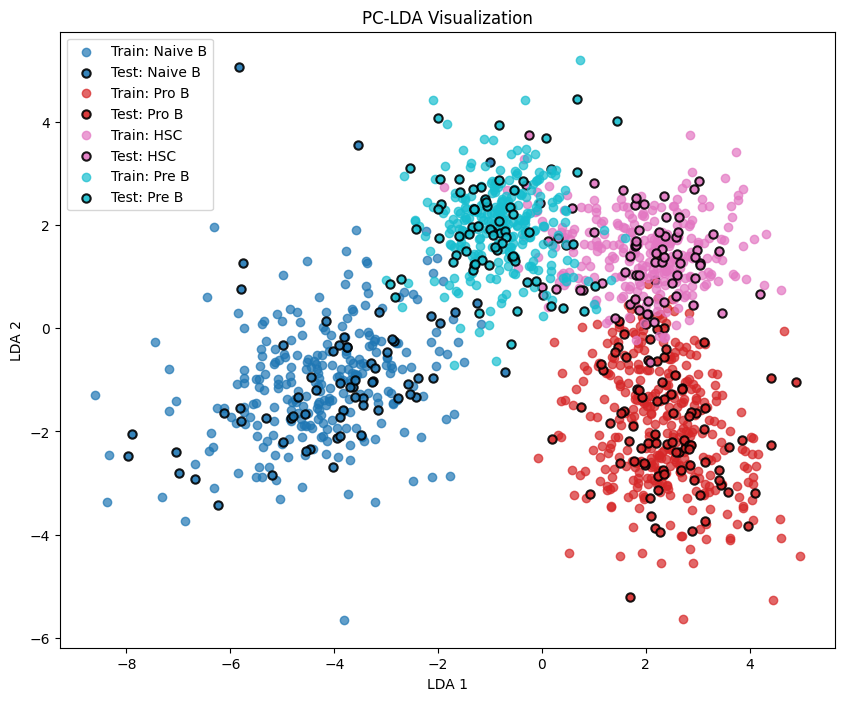

In [ ]:
plot_pclda(U_train, U_test, dims=(1, 2), title="PC-LDA Visualization")

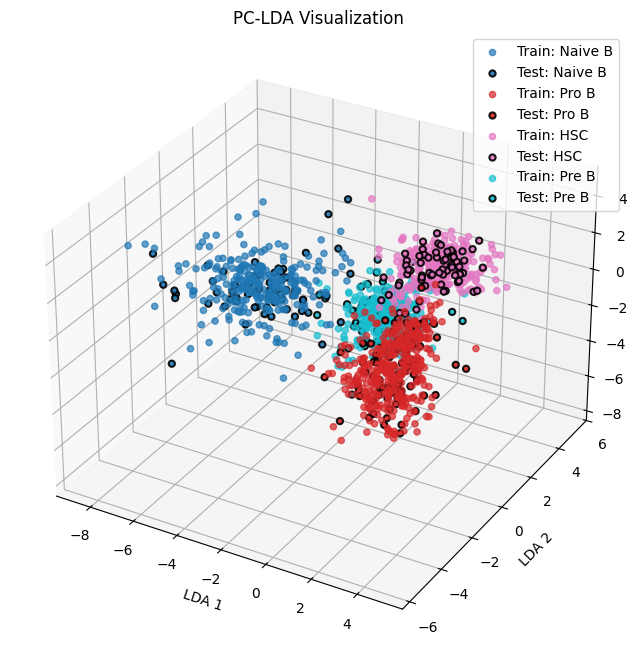

In [ ]:
plot_pclda(U_train, U_test, dims=(1, 2,3), title="PC-LDA Visualization")

In [ ]:
# Preprocess for PLSR
# raman_means, rna_means, cell_types = preprocess_for_plsr(U_train, sc_adata, group="cell_type")
raman_means_scaled, rna_means_scaled, cell_types, raman_scaler, rna_scaler = preprocess_for_plsr(U_train, sc_adata, group="cell_type")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29868\1757696867.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raman_means = U_train.groupby('group').mean().values  # (n_types, n_LDA_dims)


In [ ]:
print(f"""
    Raman mean: {raman_means_scaled}
    RNA mean: {rna_means_scaled.shape}:{rna_means_scaled}
    cell_types: {cell_types}
    """)


    Raman mean: [[ 0.81585271  0.82336448  1.31690509]
 [-1.54220578 -0.7199662   0.50564652]
 [-0.22512241  1.13117321 -1.32914863]
 [ 0.95147548 -1.23457149 -0.49340298]]
    RNA mean: (4, 2000):[[-1.56940766 -0.32501401  1.14580125 ...  1.48052669  0.07758695
   0.61570302]
 [ 0.06399948  1.18385653 -1.06304376 ...  0.05685033 -0.72700561
  -0.76113982]
 [ 0.30563766 -1.45996587 -0.92275638 ... -1.32683039 -0.95094165
  -1.15833806]
 [ 1.19977052  0.60112335  0.83999889 ... -0.21054662  1.6003603
   1.30377487]]
    cell_types: ['Naive B', 'Pro B', 'HSC', 'Pre B']
Categories (4, object): ['HSC', 'Naive B', 'Pre B', 'Pro B']
    


In [ ]:
# print(f"""
#     Raman mean: {raman_means}
#     RNA mean: {rna_means.shape}:{rna_means}
#     cell_types: {cell_types}
#     """)



    Raman mean: [[ 1.95118903  1.493052    2.03291148]
 [-4.24095358 -1.03942983  0.81592142]
 [-0.78235912  1.99814143 -1.93650244]
 [ 2.3073276  -1.88385582 -0.68277868]]
    RNA mean: (4, 33538):[[ 0.          0.          0.         ...  0.04027099  0.
   0.        ]
 [ 0.          0.          0.         ... -0.00969962  0.
   0.        ]
 [ 0.          0.          0.         ...  0.00319784  0.
   0.        ]
 [ 0.          0.          0.         ... -0.01959091  0.
   0.        ]]
    cell_types: ['Naive B', 'Pro B', 'HSC', 'Pre B']
Categories (4, object): ['HSC', 'Naive B', 'Pre B', 'Pro B']
    


In [ ]:
predictions, actuals, mse, VIP_scores, predicted_cell_types = plsr_mean_with_loocv(raman_means_scaled, rna_means_scaled, cell_types, pls_components=2)
print("Predictions:\n", predictions)
print("Actuals:\n", actuals)
print("Mean Squared Error:", mse)
print("VIP Scores:", VIP_scores)
print("Predicted cell type:", predicted_cell_types)

Predictions:
 [[ 9.45293189e+12 -5.30704273e+12 -1.72061913e+12]
 [-1.11538334e+13  3.62061340e+13  6.79387831e+12]
 [ 1.22670905e+12 -9.56823178e+12 -8.54931806e+12]
 [-1.14049140e+13 -3.99781198e+12 -1.19422975e+13]]
Actuals:
 [[ 0.81585271  0.82336448  1.31690509]
 [-1.54220578 -0.7199662   0.50564652]
 [-0.22512241  1.13117321 -1.32914863]
 [ 0.95147548 -1.23457149 -0.49340298]]
Mean Squared Error: 1.7139598496904418e+26
VIP Scores: [1.00499553 1.01981961 0.97124515 ... 1.04107386 0.94668109 0.94363386]
Predicted cell type: ['Naive B', 'Pro B', 'HSC', 'Pre B']


In [ ]:
# Perform PLSR with LOOCV
preds, actuals, mse, vip_scores, predicted_cell_types = plsr_mean_with_loocv(
    raman_means, rna_means, cell_types, pls_components=3
)

print("Predictions:\n", preds)
print("Actuals:\n", actuals)
print("Mean Squared Error:", mse)
print("VIP Scores:", vip_scores)
print("PC-LDA Accuracy:", accuracy)
print("Predicted cell type:", predicted_cell_types)

Predictions:
 [[ 1.93197524e+14 -7.25757768e+13 -1.73885068e+13]
 [-7.92257683e+11 -7.06738837e+12 -8.19372103e+12]
 [ 1.90238222e+13 -7.25042418e+13 -5.97511792e+13]
 [ 7.29516436e+12  1.29610469e+12  5.00218889e+12]]
Actuals:
 [[ 1.95118903  1.493052    2.03291148]
 [-4.24095358 -1.03942983  0.81592142]
 [-0.78235912  1.99814143 -1.93650244]
 [ 2.3073276  -1.88385582 -0.68277868]]
Mean Squared Error: 4.35679124842085e+27
VIP Scores: [0.         0.         0.         ... 1.10490968 0.         0.        ]
PC-LDA Accuracy: 0.9575971731448764
Predicted cell type: ['Naive B', 'Pro B', 'HSC', 'Pre B']


In [ ]:
U_train

,LDA_1,LDA_2,LDA_3,group
0,-2.874540,-1.455870,-3.472909,Naive B
1,-4.615121,-0.133630,0.855236,Naive B
2,3.613332,-1.982493,-1.950386,Pro B
3,2.357699,0.909926,3.450850,HSC
4,0.471531,1.639362,-1.399225,Pre B
...,...,...,...,...
1127,-2.752296,0.608570,1.433244,Naive B
1128,3.176268,-1.527800,-1.062327,Pro B
1129,1.823843,0.721416,0.800323,HSC
1130,2.776861,-0.709547,-1.328339,Pro B


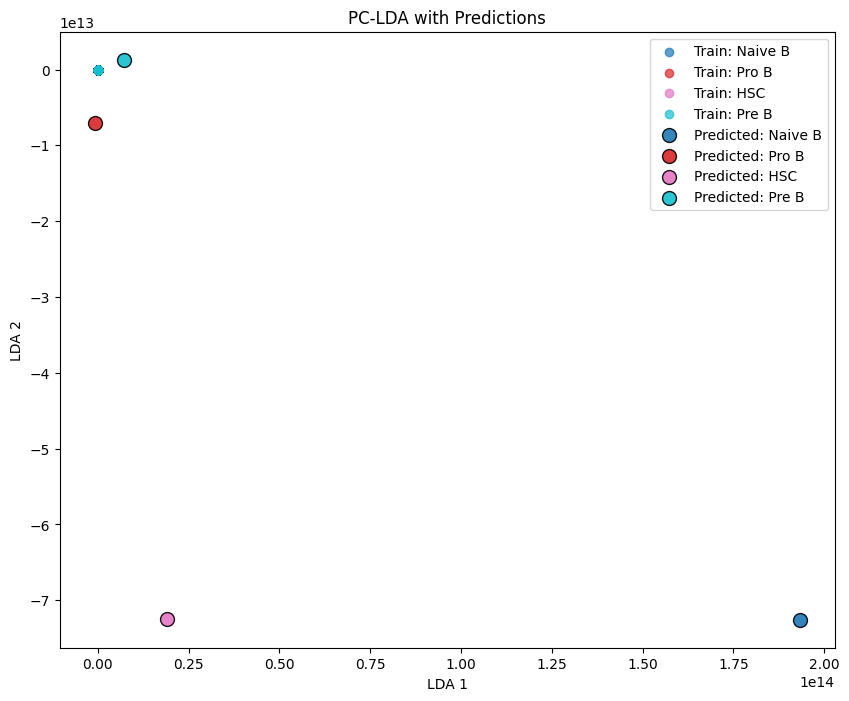

In [ ]:
plot_predictions_on_pclda(U_train, preds, predicted_cell_types, dims=(1, 2))

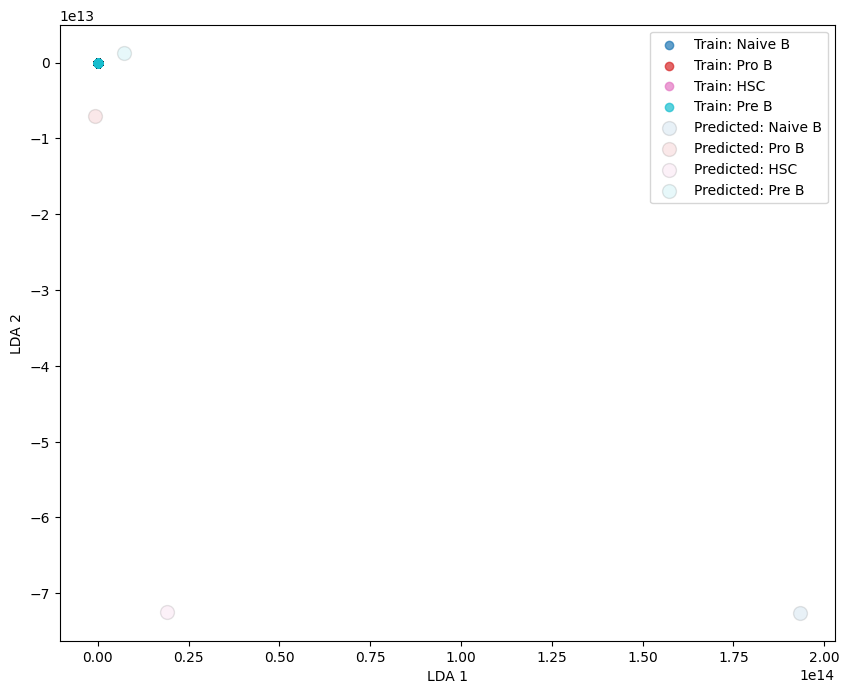

In [ ]:
dims = (1,2)
fig = plt.figure(figsize=(10, 8))

# Define consistent colors for groups
unique_groups = U_train['group'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))
group_color_map = {group: colors[i] for i, group in enumerate(unique_groups)}

ax = fig.add_subplot(111)

# Plot training data
for group in unique_groups:
    group_data_train = U_train[U_train['group'] == group]

    # Plot train data
    ax.scatter(
        group_data_train[f"LDA_{dims[0]}"],
        group_data_train[f"LDA_{dims[1]}"],
        label=f"Train: {group}",
        color=group_color_map[group],
        alpha=0.7,
    )

# Plot predictions
for pred, cell_type in zip(preds, predicted_cell_types):
    ax.scatter(
        pred[dims[0] - 1],  # dims are 1-based, adjust for 0-based indexing
        pred[dims[1] - 1],
        label=f"Predicted: {cell_type}",
        color=group_color_map[cell_type],
        edgecolor="k",
        alpha=0.1,
        marker="o",
        s=100,
    )

ax.set_xlabel(f"LDA {dims[0]}")
ax.set_ylabel(f"LDA {dims[1]}")
# ax.set_title(title)
ax.legend()
plt.show()

In [ ]:
U_train

,LDA_1,LDA_2,LDA_3,group
0,-2.874540,-1.455870,-3.472909,Naive B
1,-4.615121,-0.133630,0.855236,Naive B
2,3.613332,-1.982493,-1.950386,Pro B
3,2.357699,0.909926,3.450850,HSC
4,0.471531,1.639362,-1.399225,Pre B
...,...,...,...,...
1127,-2.752296,0.608570,1.433244,Naive B
1128,3.176268,-1.527800,-1.062327,Pro B
1129,1.823843,0.721416,0.800323,HSC
1130,2.776861,-0.709547,-1.328339,Pro B


In [ ]:
preds

array([[ 1.93197524e+14, -7.25757768e+13, -1.73885068e+13],
       [-7.92257683e+11, -7.06738837e+12, -8.19372103e+12],
       [ 1.90238222e+13, -7.25042418e+13, -5.97511792e+13],
       [ 7.29516436e+12,  1.29610469e+12,  5.00218889e+12]])

In [ ]:
pred, act, mse = plsr_two_stage_loocv(
    transcriptomes=rna_means_scaled,  
    raman=raman_means_scaled,        
    n_comp_mode="N_minus_3"
)
print("Pred shape: ", pred.shape)  # (N, d)
print("Actual shape: ", act.shape) # (N, d)
print("MSE: ", mse)


Pred shape:  (4, 3)
Actual shape:  (4, 3)
MSE:  1.1975023729985169e+26


In [ ]:
print("Pred: ", pred)  # (N, d)
print("Actual: ", act) # (N, d)
print("MSE: ", mse)


Pred:  [[-2.08918637e+11 -2.97554179e+12  1.94233694e+12]
 [-1.46258515e+13  2.90589142e+13 -1.07613408e+13]
 [-3.97346228e+12 -9.12993976e+12 -7.01511411e+12]
 [-7.62313134e+12 -6.54116971e+12  9.67024573e+11]]
Actual:  [[ 0.81585271  0.82336448  1.31690509]
 [-1.54220578 -0.7199662   0.50564652]
 [-0.22512241  1.13117321 -1.32914863]
 [ 0.95147548 -1.23457149 -0.49340298]]
MSE:  1.1975023729985169e+26


In [ ]:
import numpy as np

# 设置随机种子，方便重复
np.random.seed(42)

def generate_test_data(num_env=10, num_genes=6000, lda_dims=3):
    """
    生成一个模拟的数据集，用来测试 PLS 二阶段映射。
    - transcriptomes: (10, 6000)
    - raman: (10, 3)
    """
    # 生成转录组（10 x 6000）
    # 这里让每个基因有一定的随机均值范围，再加一些正态波动
    transcriptomes = np.random.normal(loc=0.0, scale=1.0, size=(num_env, num_genes))

    # 生成 Raman LDA 投影（10 x 3）
    # 这里假设在 3 维坐标中，每个环境略有不同中心
    # 为了稍微让它不那么全是随机，可给每行加点不同的 offset
    raman = np.zeros((num_env, lda_dims))
    for i in range(num_env):
        offset = np.array([0.5 * i, -0.3 * i, 0.2 * i])  # 模拟随环境变化的中心
        # 再加一点随机扰动
        raman[i] = offset + np.random.normal(0, 1.0, lda_dims)

    return transcriptomes, raman


In [ ]:
# 生成测试数据
transcriptomes, raman = generate_test_data(num_env=10, num_genes=6000, lda_dims=3)

print("transcriptomes shape:", transcriptomes.shape)  # (10, 6000)
print("raman shape:", raman.shape)                    # (10, 3)

print("\nExample transcriptomes (first 2 environments, first 5 genes):\n", 
        transcriptomes[:2, :5])
print("\nExample raman (first 2 environments):\n", 
        raman[:2])

transcriptomes shape: (10, 6000)
raman shape: (10, 3)

Example transcriptomes (first 2 environments, first 5 genes):
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-1.11408136 -0.63093083 -0.94206018 -0.54799582 -0.21415031]]

Example raman (first 2 environments):
 [[ 0.07883776  0.56289748  0.34110195]
 [-0.7779142  -0.4862203   0.85277955]]


In [ ]:
pred, act, mse = plsr_two_stage_loocv(
    transcriptomes=transcriptomes,  
    raman=raman,         
    n_comp_mode="N_minus_3"
)
print("Pred shape: ", pred.shape)  # (N, d)
print("Actual shape: ", act.shape) # (N, d)
print("Pred: ", pred)  # (N, d)
print("Actual: ", act) # (N, d)
print("MSE: ", mse)


Pred shape:  (10, 3)
Actual shape:  (10, 3)
Pred:  [[ 2.8239626  -1.76822732  1.18512778]
 [ 2.87105462 -1.64495899  1.11776234]
 [ 2.42667485 -1.45852241  0.93258199]
 [ 2.3499281  -1.45268532  1.36195221]
 [ 2.11124946 -1.48300559  1.23697464]
 [ 2.41197527 -1.46906011  0.94129811]
 [ 2.69949498 -1.47097532  0.8780161 ]
 [ 2.20061892 -1.51250335  0.95604   ]
 [ 2.36874196 -1.42169018  1.14917561]
 [ 2.06631041 -1.31818836  0.97776667]]
Actual:  [[ 0.07883776  0.56289748  0.34110195]
 [-0.7779142  -0.4862203   0.85277955]
 [ 1.41804032 -1.38187042  0.81590347]
 [ 2.41488925 -1.87629904 -1.36023374]
 [ 3.77406339 -0.88466509  0.34270817]
 [ 2.00844471 -1.35320946  2.04101841]
 [ 1.49021186 -2.20094456  2.85396742]
 [ 4.32461896 -1.36069228  1.80769651]
 [ 4.31048128 -2.8681751   1.04178348]
 [ 5.30613245 -3.23960756  2.08383258]]
MSE:  2.4931480665710084
